# 1. Logarithms and exponentials: multiplication, inverse rules, and numerical stability

Learn to interpret exponential growth, calculate logarithms as inverse questions, apply basic log identities, and avoid two common floating-point failures. Prerequisite: [linear and quadratic equations](../../../02_Mathematics_for_ML/05_linear_and_quadratic_equations.ipynb) and powers. All growth data are invented. We will implement calculations directly before using NumPy and a standard scientific-library stability routine.

## 2. What problem does this solve?

Repeated addition produces a straight-line pattern. Repeated multiplication produces exponential change. If a quantity doubles at each step, asking how much exists after three steps uses an exponent. Asking how many steps are needed to reach a specified amount uses a logarithm.

Machine learning uses exponentials to convert scores into positive quantities and logarithms to turn products into sums or penalize low assigned probabilities. Those computations can overflow even when the final quantity is manageable. Understanding the mathematical identities lets us reorganize the computation without changing its meaning.

## 3. Intuition and analogy

Imagine starting with ten tokens and doubling them at each round. After one round you have twenty, after two forty, after three eighty. A logarithm works backward through that multiplication history: how many doublings take ten to eighty? The answer is three.

A calculator display is not the real-number system. It has a finite range and finite precision. An enormous intermediate exponential can overflow before a later logarithm brings it back to a reasonable scale. A tiny increment can vanish when added to one. Stable identities avoid constructing those troublesome intermediate values.

## 4. Terminology

An **exponential function** places its input in an exponent. A **logarithm** answers the inverse question: what exponent produces this positive value? The **base** specifies the repeated multiplier. The **natural logarithm**, written $\ln$, uses base $e\approx2.71828$. NumPy's `log` is the natural logarithm, while `log2` uses base two.

**Overflow** means a computation exceeds the representable numerical range. **Underflow** means a tiny magnitude may become zero or lose precision. **Cancellation** or rounding can erase a small difference or increment. **Log-sum-exp** is the logarithm of a sum of exponentials; a shifted computation evaluates it without forming unnecessarily huge exponential terms.

## 5. Mathematical foundations

For base $b>0$ with $b\ne1$,

$$y=b^x\quad\Longleftrightarrow\quad x=\log_b(y),\qquad y>0.$$

$b$ is a dimensionless base, $x$ a dimensionless exponent, and $y$ a positive dimensionless output. The double arrow means the statements are equivalent. For positive $u$ and $v$, $\log_b(uv)=\log_b(u)+\log_b(v)$. Also $\log_b(u^k)=k\log_b(u)$ for real $k$ under these positive-input conditions. There is no analogous rule turning a log of a sum into a sum of logs.

For an amount $A(t)=A_0\,2^{t/\tau}$, $A_0$ is the starting amount, $t$ elapsed time, and $\tau$ the doubling time in the same time units. The exponent $t/\tau$ has no units. The inverse is $t=\tau\log_2(A/A_0)$; the ratio inside the logarithm is dimensionless. Taking a logarithm of a quantity without a reference unit obscures its meaning.

## 6. Hand-calculated example

With ten tokens and doubling time one round, after three rounds $A=10\times2^3=80$ tokens. Reversing it gives $t=1\times\log_2(80/10)=\log_2(8)=3$ rounds. Since $8\times4=32$, $\log_2(32)=5$, which equals $\log_2(8)+\log_2(4)=3+2$.

The natural-log version is $2^x=e^{x\ln2}$. At $x=3$, the exponent is approximately $3\times0.693147=2.079442$, whose natural exponential is eight. For a predicted probability assigned to a correct event, a simple negative-log score is $-\ln p$: at $p=1$ it is zero, at $p=1/2$ about 0.693, and at $p=1/4$ about 1.386. A probability is a stated chance between zero and one; this score evaluates confidence in an observed event, not a count of errors.

## 7. Direct implementation

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
import math
initial_tokens = 10.0
doubling_rounds = 1.0
elapsed_rounds = 3.0
amount = initial_tokens * 2 ** (elapsed_rounds / doubling_rounds)
recovered_rounds = doubling_rounds * math.log2(amount / initial_tokens)
assert amount == 80.0 and recovered_rounds == 3.0
assert math.log2(8 * 4) == math.log2(8) + math.log2(4) == 5
assert math.isclose(math.exp(3 * math.log(2)), 8.0)
print('Amount:', amount, 'tokens; recovered time:', recovered_rounds, 'rounds')

Amount: 80.0 tokens; recovered time: 3.0 rounds


These coefficients define a hypothetical growth rule. No dataset has estimated them. Fractional rounds are a continuous interpolation assumption rather than proof of how a real discrete process behaves between rounds.

## 8. Inspect domains and inverses

Real logarithms require positive inputs. Zero has no finite real logarithm, and negative inputs have no real logarithm. We reject invalid values explicitly before calling the numerical routine. This also distinguishes a legitimate negative logarithm, such as the log of a positive fraction, from an invalid negative input.

In [3]:
def positive_log(value):
    if isinstance(value, bool) or not isinstance(value, (int, float)):
        raise ValueError('Use an ordinary positive finite number.')
    if not math.isfinite(value) or value <= 0:
        raise ValueError('The real logarithm requires a positive finite input.')
    return math.log(value)

assert positive_log(1) == 0
assert positive_log(0.5) < 0
for invalid in [0, -1, math.inf, math.nan, True]:
    try:
        positive_log(invalid)
    except ValueError:
        pass
    else:
        raise AssertionError('Invalid real-log input was accepted.')
print('ln(0.5):', positive_log(0.5), '; ln(1):', positive_log(1))

ln(0.5): -0.6931471805599453 ; ln(1): 0.0


## 9. NumPy and scientific-library implementations

NumPy applies logarithms and exponentials elementwise. A probability vector here has shape `(3,)`; each element receives one negative-log score. We also show a shifted log-sum-exp mechanism before comparing it with SciPy's tested implementation. SciPy is already present in the project environment.

For finite scores $s_1,\ldots,s_n$, let $m=\max_i s_i$. Then

$$\ln\left(\sum_i e^{s_i}\right)=m+\ln\left(\sum_i e^{s_i-m}\right).$$

Each $s_i$ and $m$ is dimensionless; the score vector has shape $(n,)$ and the result is one scalar. Factoring $e^m$ out of the sum proves the identity. Every shifted exponent is at most zero, avoiding huge positive exponentials.

In [4]:
import numpy as np
from scipy.special import logsumexp
probabilities = np.array([1.0, 0.5, 0.25])
negative_log_scores = -np.log(probabilities)
np.testing.assert_allclose(negative_log_scores, [0, math.log(2), 2 * math.log(2)])

def shifted_logsumexp(scores):
    values = list(scores)
    if not values or any(isinstance(v, bool) or not isinstance(v, (int, float)) or not math.isfinite(v) for v in values):
        raise ValueError('Use a nonempty sequence of finite ordinary scores.')
    largest = max(values)
    return largest + math.log(math.fsum(math.exp(value - largest) for value in values))

scores = [1000.0, 1001.0]
stable_result = shifted_logsumexp(scores)
expected = 1001 + math.log1p(math.exp(-1))
assert math.isclose(stable_result, expected)
assert math.isclose(stable_result, float(logsumexp(scores)))
print('Stable log-sum-exp:', stable_result)

Stable log-sum-exp: 1001.3132616875182


## 10. Visualization

Plot doubling alongside the natural log. The first rises multiplicatively; the second increases slowly and crosses zero at input one. The horizontal inputs mean different things in each panel, so labels distinguish elapsed rounds from a dimensionless positive ratio. The log plot deliberately excludes zero.

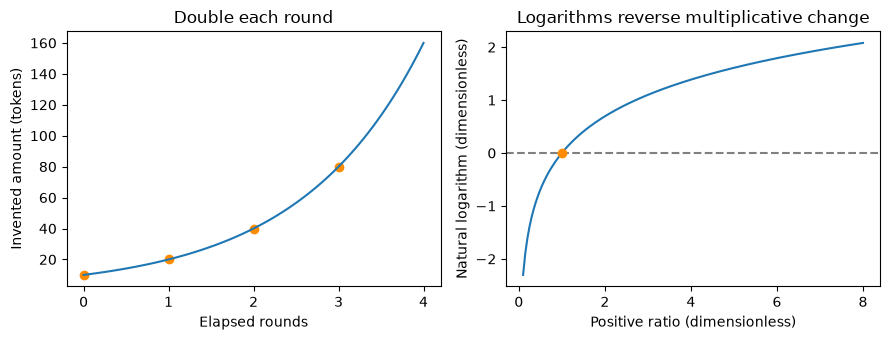

In [5]:
import matplotlib.pyplot as plt
round_grid = np.linspace(0, 4, 81)
ratios = np.linspace(0.1, 8, 160)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(round_grid, 10 * 2 ** round_grid)
axes[0].scatter([0, 1, 2, 3], [10, 20, 40, 80], color='darkorange')
axes[0].set(xlabel='Elapsed rounds', ylabel='Invented amount (tokens)', title='Double each round')
axes[1].plot(ratios, np.log(ratios))
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].scatter([1], [0], color='darkorange', zorder=3)
axes[1].set(xlabel='Positive ratio (dimensionless)', ylabel='Natural logarithm (dimensionless)', title='Logarithms reverse multiplicative change')
fig.tight_layout()
display(fig)
plt.close(fig)

## 11. Experiment: two numerical failures

`log(exp(1000)+exp(1001))` overflows at the exponential step in ordinary double precision. We deliberately silence only that expected overflow warning inside a scoped block, then check the resulting infinity. The shifted expression remains finite. Separately, adding $10^{-16}$ to one rounds to one on this numerical representation; `log1p` computes the small log increment directly.

In [6]:
with np.errstate(over='ignore'):
    naive = np.log(np.exp(np.array(scores)).sum())
assert np.isinf(naive) and np.isfinite(stable_result)
tiny = 1e-16
naive_small = np.log(1.0 + tiny)
stable_small = np.log1p(tiny)
assert naive_small == 0 and stable_small > 0
assert math.isclose(float(stable_small), tiny, rel_tol=1e-12)
print('Naive large-score result:', naive, 'Stable result:', stable_result)
print('Naive small-increment result:', naive_small, 'log1p result:', stable_small)

Naive large-score result: inf Stable result: 1001.3132616875182
Naive small-increment result: 0.0 log1p result: 1e-16


The stable log-sum-exp helper covers finite ordinary scores only. Infinite scores and empty inputs require additional policies. Stable rearrangement improves this mechanism; it does not promise immunity to every extreme finite input or downstream rounding error.

## 12. Choices and fitted quantities

Log base determines numerical scale. Natural logs are conventional in many likelihood and loss formulas; base two measures corresponding information quantities in bits when the probabilistic definitions apply. Base change follows $\log_b u=\ln u/\ln b$. Our growth rate and starting amount are supplied coefficients, not learned parameters. No predictive hyperparameters are optimized here.

## 13. Evaluation

Check hand powers, inverse recovery, log identities under valid domains, NumPy agreement, and the stable computation against an independently supplied scientific routine. Test the domain before evaluating a log. For transformed measurements, retain the reference and inverse rule so you can return to the original units when appropriate.

In [7]:
positive_values = np.array([0.25, 1.0, 2.0, 8.0])
np.testing.assert_allclose(np.exp(np.log(positive_values)), positive_values)
np.testing.assert_allclose(np.log2(positive_values), np.log(positive_values) / np.log(2))
for values in [[0.0, 0.0], [-1000.0, -1001.0], [3.0]]:
    assert math.isclose(shifted_logsumexp(values), float(logsumexp(values)), abs_tol=1e-12)
print('Inverse, base change, and shifted-sum checks passed.')

Inverse, base change, and shifted-sum checks passed.


## 14. Assumptions and limitations

Positive-input domains are essential. A log transform does not make every dataset normal or every relationship linear. `log1p(x)` computes $\ln(1+x)$ and still requires $x>-1$ for a finite real result. Adding an arbitrary constant to allow nonpositive measurements changes the transformation and its interpretation. Exponential growth cannot describe unlimited real-world resource expansion without considering constraints.

## 15. Common mistakes and debugging

Do not confuse `np.log` with base-ten logarithms. Do not apply log rules to sums: $\ln(u+v)$ is generally not $\ln u+\ln v$. Do not replace invalid log outputs with zero and continue silently. Check units through a dimensionless ratio. Use `log1p` and the shifted-sum identity when their mathematical forms match the computation, rather than clipping values without explanation.

For a probability of exactly zero, negative log is infinite. That is a meaningful mathematical penalty under this score, but a real model implementation needs an explicit numerical or modeling policy. Clipping probabilities changes the evaluated quantity and should be disclosed.

## 16. Alternatives and connections

Linear differences describe additive changes; ratios and logarithms describe multiplicative changes. Direct exponentials are fine in a moderate range, while shifted log calculations help when scores are large. A logarithmic chart axis changes the display; transforming a feature changes numerical inputs to later analysis. Those operations are related but not interchangeable. Later probability lessons explain why log-likelihoods are useful.

## 17. Exercises

- **Beginner:** Starting with five tokens, calculate the amount after four doublings and recover the round count.
- **Beginner:** Calculate $\log_2(1)$, $\log_2(16)$, and $\log_2(1/4)$.
- **Beginner:** Explain why $\ln(0.5)$ is valid while $\ln(-0.5)$ is not a real value.
- **Intermediate:** Use the product identity to calculate $\log_2(8\times16)$ without multiplying first.
- **Intermediate:** Explain why an exponential followed by a logarithm can fail computationally even when the final real-number answer is finite.
- **Challenge:** Compute stable two-score log-sum-exp for `[10000,9999]`, check shift invariance, and reject empty/nonfinite inputs. Explain each algebraic step.

## 18. Detailed solutions

Five tokens become $5\times2^4=80$; $\log_2(80/5)=4$. The three logarithms are zero, four, and minus two. A positive fraction has a negative logarithm because a negative exponent produces it; a negative argument is outside the real-log domain. The product log is $3+4=7$. Large intermediate exponentials may overflow before the log is applied.

For the challenge, take the maximum 10000. The shifted exponents are zero and minus one, so the answer is $10000+\ln(1+e^{-1})$. Adding a common constant $k$ to every score multiplies the exponential sum by $e^k$, so its log increases by $k$. That is shift invariance of the centered mechanism, not invariance of the final scalar value.

In [8]:
assert 5 * 2 ** 4 == 80 and math.log2(80 / 5) == 4
assert [math.log2(v) for v in [1, 16, 0.25]] == [0, 4, -2]
assert math.log2(8) + math.log2(16) == 7
large = [10000.0, 9999.0]
answer = shifted_logsumexp(large)
assert math.isclose(answer, 10000 + math.log1p(math.exp(-1)))
shift = 17.0
assert math.isclose(shifted_logsumexp([v + shift for v in large]), answer + shift)
for invalid in [[], [math.inf], [math.nan], [True]]:
    try:
        shifted_logsumexp(invalid)
    except ValueError:
        pass
    else:
        raise AssertionError('Invalid log-sum-exp inputs were accepted.')
print('Growth, logarithm, and stable-shift exercises passed.')

Growth, logarithm, and stable-shift exercises passed.


## 19. Knowledge check

**What question does a logarithm answer?** Which exponent of the chosen base produces a positive value.

**What base does np.log use?** The natural base e.

**Why use a ratio inside a measurement log?** It makes the argument dimensionless and states its reference.

**Why subtract the maximum before exponentiating?** It makes all exponents nonpositive while preserving a recoverable common factor.

**Does log1p mean log base one?** No. It computes the natural log of one plus its input with better small-increment accuracy.

## 20. Interview preparation

**Why turn products into log sums?** It simplifies multiplicative quantities and can reduce numerical underflow in later likelihood computations.

**How is log-sum-exp stabilized?** Factor out the largest exponential, sum shifted exponentials, and add the maximum back after taking the log.

**Why is log of a sum not a sum of logs?** The product identity applies to multiplication; applying it to addition changes the mathematical quantity.

**Can changing log base alter comparisons?** For bases greater than one it rescales logs by a positive constant, though numerical values and units of information change.

**Does a logarithmic transform solve all skewness problems?** No. Domain, data-generating process, zeros, and the later modeling objective still matter.

## 21. Summary and next steps

Exponents describe multiplicative change; logs reverse it and turn products into sums under valid domains. Stable identities preserve useful results when naive intermediates fail. Continue to [scalars, vectors, and matrices](../../../02_Mathematics_for_ML/07_scalars_vectors_and_matrices.ipynb), then [vector addition and multiplication](../../../02_Mathematics_for_ML/08_vector_addition_and_multiplication.ipynb).